Quanitfy the difference between two ShakeMaps. To be run in env `shakemap`


## Read in and prepare datasets

In [204]:
#!/usr/bin/env python
"""
Compare two shakemaps.
"""
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mapio.shake import ShakeGrid

# -------------------------
# USER INPUT
# -------------------------

# eventlist = [
#     'us6000jlqa',
#     "us60007idc",
#     "ci38457511",
# ]

# eventlist = [
#     'us6000n8tq',
#     'us6000qw60',
# ]
# eventtypelist = [
#     ''
# ]
# eventid = 'us2000d7q6'
eventid= 'us6000jllz'
eventtype='np2'    # 'np1-2', 'slab2', 

datadir = '/Users/hyin/shakemap_profiles/default/data/'

# for eventid in eventlist: 
#     grid1='/Users/hyin/shakemap_profiles/default/data/us6000jlqa/ffsimmer_pointsource/products/grid.xml'
#     grid2 = '/Users/hyin/shakemap_profiles/default/data/us6000jlqa/np1/products/grid.xml'
#     grid3 = '/Users/hyin/shakemap_profiles/default/data/us6000jlqa/shakemap_reproduction/products/grid.xml'

grid1=f'/Users/hyin/shakemap_profiles/default/data/{eventid}/ffsimmer_pointsource/products/grid.xml'
grid2 = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/{eventtype}/products/grid.xml'
grid3 = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/shakemap_reproduction/products/grid.xml'
# grid4 = '/Users/hyin/shakemap_profiles/default/data/us7000pn9s/shakemap_reproduction/products/grid.xml'

grid_files = [
    grid1,
    grid2,
    grid3,
    # grid4,
]
labels = ["Unconstrained",f"{eventtype}","Finite Fault"]

imt = "mmi"
threshold = 1.0
output = f'/Users/hyin/shakemap_profiles/default/data/{eventid}/comparison/'




## Load grids

In [205]:

# -------------------------
# LOAD GRIDS
# -------------------------
grids = [ShakeGrid.load(f).getData()[imt] for f in grid_files]
geodicts = [g.getGeoDict() for g in grids]

# Cut grids to their common overlapping region. 
cutdict = geodicts[0]
for gd in geodicts[1:]:
    try:
        cutdict = cutdict.getBoundsWithin(gd)
    except Exception:
        cutdict = gd.getBoundsWithin(cutdict)

# Interpolate all grids to common grid
interp_grids = [g.interpolateToGrid(cutdict) for g in grids]
arrays = [g.getData() for g in interp_grids]

# Coordinates
ny, nx = arrays[0].shape
lats = np.linspace(cutdict.ymin, cutdict.ymax, ny)
lons = np.linspace(cutdict.xmin, cutdict.xmax, nx)


## Plot ShakeMap comparison grid

/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_67348/3474509275.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to: /Users/hyin/shakemap_profiles/default/data/us6000jllz/comparison/comparison_matrix.png


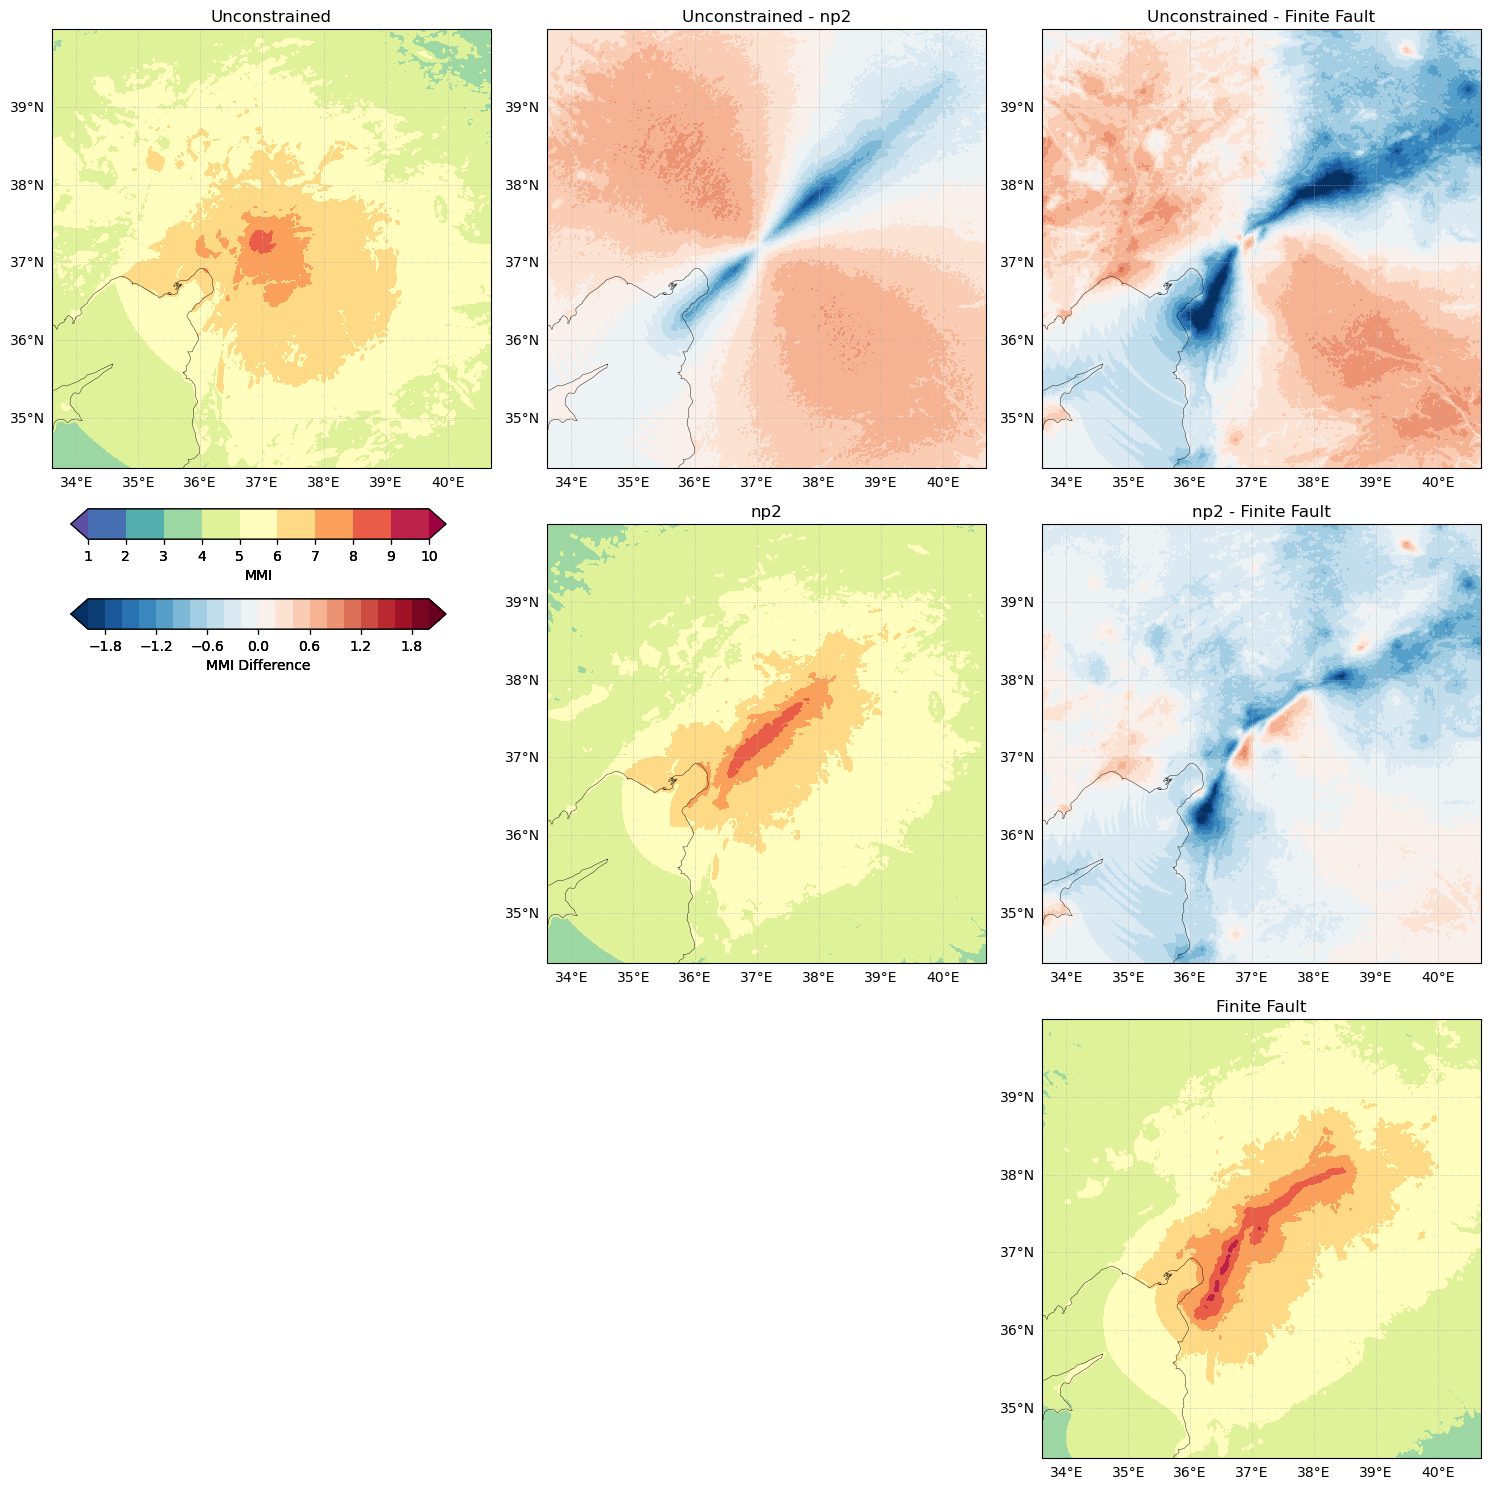

In [251]:
# Number of grids being plotted
n = len(arrays)

mmi_levels = np.linspace(1, 10, 10)
diff_levels = np.linspace(-2.0, 2.0, 21)

# Creates 2 rows and 2 columns (4 plots total)
fig, axs = plt.subplots(n , n , figsize=(5*n, 5*n), subplot_kw={'projection': ccrs.PlateCarree()}) 

for i in range(n):
    for j in range(n):
        data = arrays[i]
        # Only fill upper triangle (including diagonal)
        if j < i:
            axs[i, j].set_visible(False)
            continue
        elif i == j:
            # -------------------------
            # DIAGONAL: original maps
            # -------------------------
            
            # Plot Top-left
            cs = axs[i, j].contourf(
                lons, lats, np.flipud(data),
                mmi_levels, cmap=plt.cm.Spectral_r, extend="both"
            )

            # Ensure aspect ratio matches map
            axs[i, j].set_aspect((lons.max() - lons.min()) / (lats.max() - lats.min()))
            # Add Coastlines
            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            # Add gridlines to bottom and lefthand sides only
            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False
            axs[i, j].set_title(labels[i])

            # MMI colorbar
            cax1_width = 1/(n+1)    # center color bar below Top Left subplot
            cax1_height = ((n-1)/n) - 0.03
            cax1 = fig.add_axes([0.05, cax1_height, cax1_width, 0.02])   # left, bottom, width, height
            fig.colorbar(cs, cax=cax1, orientation="horizontal").set_label("MMI")

        elif i< j:
            # -------------------------
            # OFF-DIAGONAL: pairwise difference
            # -------------------------
            a = arrays[i].copy()
            b = arrays[j].copy()

            # Shared mask
            mask = (a < threshold) & (b < threshold)
            a[mask] = np.nan
            b[mask] = np.nan

            diff = a-b
            rms = np.sqrt(np.nanmean(diff**2))

            cs = axs[i, j].contourf(
                lons, lats, np.flipud(diff),
                diff_levels, cmap=plt.cm.RdBu_r, extend="both"
            )

            # Ensure aspect ratio matches map
            axs[i, j].set_aspect((lons.max() - lons.min()) / (lats.max() - lats.min()))
            # Add Coastlines
            axs[i, j].coastlines(resolution='10m', linewidth=0.3)

            # Add gridlines to bottom and lefthand sides only
            gl = axs[i, j].gridlines(draw_labels=True, linewidth=0.5, linestyle='dotted')
            gl.top_labels = False
            gl.right_labels = False
            axs[i, j].set_title(labels[i])
            
            # Diff colorbar
            cax2_width = 1/(n+1)    # center color bar below Top Left subplot
            cax2_height = ((n-1)/n) - 0.09
            cax2 = fig.add_axes([0.05, cax2_height, cax2_width, 0.02])   # left, bottom, width, height
            fig.colorbar(cs, cax=cax2, orientation="horizontal").set_label("MMI Difference")

            axs[i, j].set_title(f"{labels[i]} - {labels[j]}")   # \nRMS={rms:.2f}
        else:
            continue
plt.tight_layout()
plt.savefig(f"{output}comparison_matrix.png", dpi=300)
print(f"Saved to: {output}comparison_matrix.png")

## Plot a single area-intensity distribution plot

In [139]:
import numpy as np
import matplotlib.pyplot as plt

def geodict_bounds(gd):
    """
    Extract xmin, xmax, ymin, ymax, dx, dy from a GeoDict-like object or dict.
    Tries attributes first, falls back to dict keys.
    """
    def get(obj, name, alt=None):
        if hasattr(obj, name):
            return getattr(obj, name)
        if alt is not None and name in obj:
            return obj[name]
        # try common alternatives
        alts = {'xmin':['minx','x_min'], 'xmax':['maxx','x_max'],
                'ymin':['miny','y_min'], 'ymax':['maxy','y_max'],
                'dx':['xdim','xres'], 'dy':['ydim','yres']}
        for k in alts.get(name, []):
            if hasattr(obj, k): return getattr(obj, k)
            if isinstance(obj, dict) and k in obj: return obj[k]
        raise AttributeError(f"Could not find {name} in GeoDict")
    xmin = get(gd, 'xmin')
    xmax = get(gd, 'xmax')
    ymin = get(gd, 'ymin')
    ymax = get(gd, 'ymax')
    dx   = get(gd, 'dx')
    dy   = get(gd, 'dy')
    return xmin, xmax, ymin, ymax, dx, dy

def pixel_area_grid_latlon(shape, gd):
    """
    Approximate per-pixel area (km^2) for an evenly spaced lon/lat raster.
    Assumes PlateCarree (degrees). Area varies with latitude: ~ R^2 * dlon_rad * dlat_rad * cos(lat).
    Returns 2D array of areas matching 'shape'.
    """
    R = 6371.0  # Earth radius in km
    xmin, xmax, ymin, ymax, dx, dy = geodict_bounds(gd)
    ny, nx = shape

    # Build latitude centers from bounds; confirm orientation matches array indexing.
    # Many ShakeMap arrays are displayed origin='lower'. Here we create latitudes from bottom (ymin) to top (ymax).
    lats = np.linspace(ymin + dy/2, ymax - dy/2, ny)  # center of each row
    dlat = np.deg2rad(dy)
    dlon = np.deg2rad(dx)

    # area per row (km^2 per pixel), broadcast to full grid
    row_area = (R * dlat) * (R * dlon) * np.cos(np.deg2rad(lats))  # shape (ny,)
    return np.broadcast_to(row_area[:, None], (ny, nx))  # shape (ny, nx)

def exceedance_area(arr, thresholds, area_grid):
    """
    Area exceedance for array 'arr' at given thresholds.
    Returns area_km2 (per threshold), area_fraction (per threshold), total_area_km2.
    """
    # Handle MaskedArray -> NaN
    data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    finite = np.isfinite(data)
    total_area = area_grid[finite].sum()
    areas = np.array([area_grid[finite & (data >= t)].sum() for t in thresholds], dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)
    return areas, fracs, total_area

def binned_area(arr, bin_edges, area_grid):
    """
    Compute area within each magnitude bin.

    Parameters
    ----------
    arr : 2D array
        Magnitude (e.g., MMI) grid.
    bin_edges : 1D array
        Bin edges (length N+1 defines N bins).
        Example: np.arange(1.0, 10.5, 0.5)
    area_grid : 2D array
        Per-pixel area (km^2), same shape as arr.

    Returns
    -------
    areas : 1D array
        Area (km^2) in each bin.
    fracs : 1D array
        Fraction of total valid area in each bin.
    total_area : float
        Total valid area (km^2).
    """
    # Handle MaskedArray -> NaN
    # data = arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr
    data = arr
    finite = np.isfinite(data)

    total_area = area_grid[finite].sum()

    areas = []
    for i in range(len(bin_edges) - 1):
        lo = bin_edges[i]
        hi = bin_edges[i + 1]

        # Left-inclusive, right-exclusive except last bin
        if i == len(bin_edges) - 2:
            mask = finite & (data >= lo) & (data <= hi)
        else:
            mask = finite & (data >= lo) & (data < hi)

        areas.append(area_grid[mask].sum())

    areas = np.array(areas, dtype=float)
    fracs = areas / total_area if total_area > 0 else np.zeros_like(areas)

    return areas, fracs, total_area

In [273]:
import numpy as np
import matplotlib.pyplot as plt
from mapio.shake import ShakeGrid
# -------------------------
# LOAD + ALIGN GRIDS
# -------------------------
# Get grid data for the IMT of interest
grids = [ShakeGrid.load(f).getData()[imt] for f in grid_files]  # grids = list of grid objects (one per user-provided grid)
geodicts = [g.getGeoDict() for g in grids]

print(geodicts[0])

# Find common bounds
cutdict = geodicts[0]   # start with the first grid
for gd in geodicts[1:]: # Compare each other grid to the first grid
    try:
        cutdict = cutdict.getBoundsWithin(gd)
    except Exception:
        cutdict = gd.getBoundsWithin(cutdict)
# end up with cutdict, which is the common overlapping region across all grids
print(cutdict)

# Interpolate all grids
# Resamples each grid so they all:
    # cover the same region
    # have same resolution
    # align cell-by-cell
interp_grids = [g.interpolateToGrid(cutdict) for g in grids]
arrays = [g.getData() for g in interp_grids]    # Extracts raw numpy arrays from each grid
# arrays = list of 2D arrays (same shape)

print(arrays[0])

Bounds: (33.6000,40.7142,34.3220,40.0000)
Dims: (0.0167,0.0167)
Shape: (341,427)
Bounds: (33.6097,40.6905,34.3538,39.9984)
Dims: (0.0167,0.0167)
Shape: (339,425)
[[4.1       4.1       4.1       ... 3.8095808 3.8095808 3.8095808]
 [4.095984  4.1       4.094435  ... 3.904016  3.9       3.905565 ]
 [4.052519  4.084854  4.0338845 ... 3.9379003 3.9       3.9580839]
 ...
 [3.8       3.852519  3.8959842 ... 4.081365  4.0676646 4.104016 ]
 [3.8       3.8       3.852519  ... 4.048503  4.148503  4.1379004]
 [3.8       3.8       3.8       ... 3.948503  4.042938  4.0864034]]


In [ ]:


## Calculate Areas: 
R = 6371  # km
dlat = np.radians(lats[1] - lats[0])
dlon = np.radians(lons[1] - lons[0])

lats_rad = np.radians(lats)
area_per_row = R**2 * dlat * dlon * np.cos(lats_rad)

area_grid = np.repeat(area_per_row[:, np.newaxis], nx, axis=1)

area_grid.shape == arrays[0].shape

# -------------------------
# BINNING
# -------------------------
# Compute bin boundaries
bin_edges = np.arange(1.0, 10.5, 0.5)
# compute the midpoint of each bin (useful for plotting later)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_areas = []

print("area_grid shape:", area_grid.shape)
print("array shape:", arrays[0].shape)


for arr in arrays:    
    area, frac, total_area = binned_area(arr, bin_edges, area_grid)
    bin_areas.append(area)

bin_areas = np.array(bin_areas)  # shape: (n_grids, n_bins)


Bounds: (33.6097,40.6905,34.3538,39.9984)
Dims: (0.0167,0.0167)
Shape: (339,425)
area_grid shape: (339, 425)
array shape: (339, 425)


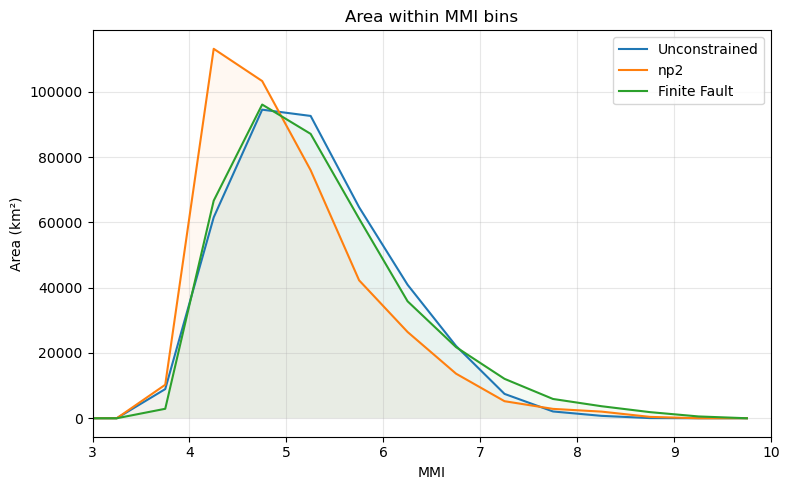

In [257]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n):
    y = bin_areas[i]
    ax.plot(bin_centers, y, label=labels[i])
    ax.fill_between(bin_centers, y, alpha=0.05)

ax.set_xlim(3,10)
# ax.set_ylim(0,40000)

ax.set_xlabel("MMI")
ax.set_ylabel("Area (km²)")
ax.set_title("Area within MMI bins")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(f"{output}/MMI_area-intensity-dist.png", dpi=200)
plt.show()

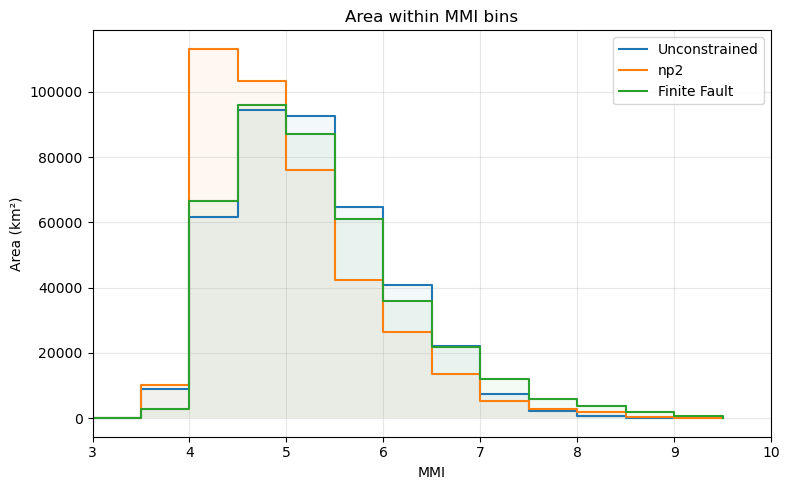

In [299]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n):
    y = bin_areas[i]
    
    ax.step(bin_edges[:-1], y, where='post', label=labels[i])
    ax.fill_between(bin_edges[:-1], y, step='post', alpha=0.05)

ax.set_xlim(3, 10)
ax.set_xlabel("MMI")
ax.set_ylabel("Area (km²)")
ax.set_title("Area within MMI bins")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

/var/folders/x7/q8y3dbkj0gv831q8bnwtym_c0000gp/T/ipykernel_67348/229603290.py:10: RuntimeWarning: invalid value encountered in divide
  delta = bin_areas[i]/ref


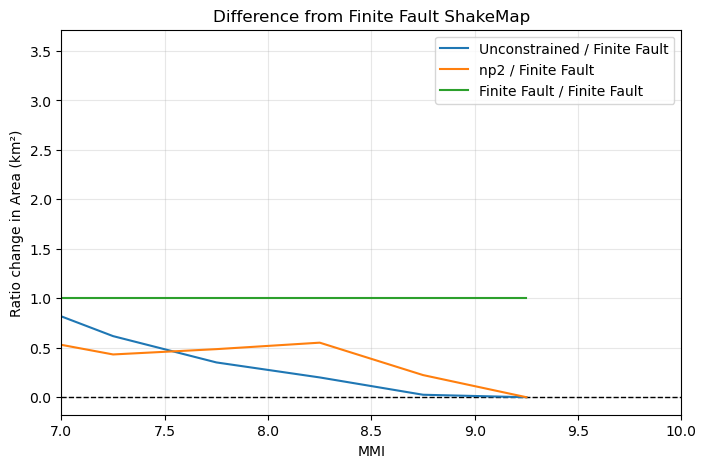

In [ ]:
ref_idx = -1  # choose baseline as last grid
ref = bin_areas[ref_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, linestyle="--", color="k", linewidth=1)

for i in range(len(bin_areas)):
    if i == ref_idx:
        continue
    delta = bin_areas[i]/ref
    ax.plot(bin_centers, delta, label=f"{labels[i]} / {labels[ref_idx]}")

ax.set_xlabel("MMI")
ax.set_ylabel("Ratio change in Area (km²)")
ax.set_title(f"Difference from {labels[ref_idx]} ShakeMap")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(7.0,10.0)

plt.savefig(f"{output}/MMI_area-intensity-dist_comparison.png", dpi=200)
plt.show()

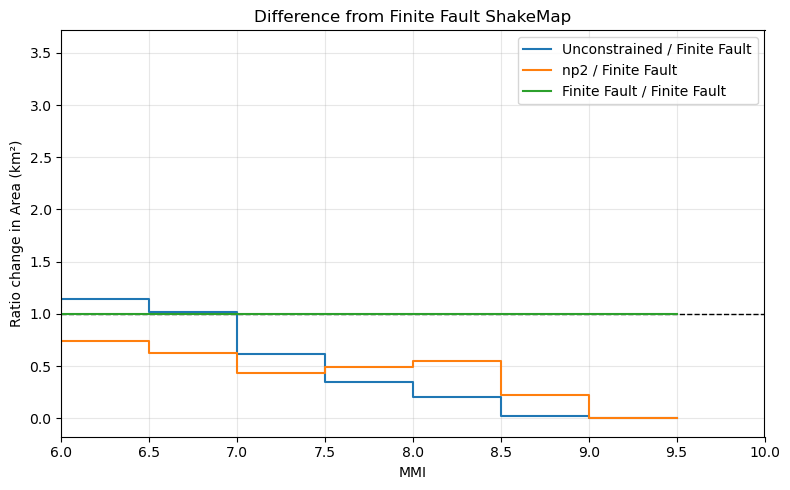

In [302]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(1, linestyle="--", color="k", linewidth=1)  # ratio baseline = 1

ref_idx = -1
ref = bin_areas[ref_idx]

for i in range(len(bin_areas)):
    if i == ref_idx:
        continue

    # safe division (avoid NaNs/inf from zeros in ref)
    delta = np.divide(
        bin_areas[i], ref,
        out=np.full_like(ref, np.nan),
        where=ref != 0
    )

    ax.step(
        bin_edges[:-1], delta,
        where='post',
        label=f"{labels[i]} / {labels[ref_idx]}"
    )

    # ax.fill_between(
    #     bin_edges[:-1], delta,
    #     step='post',
    #     alpha=0.05
    # )

ax.set_xlabel("MMI")
ax.set_ylabel("Ratio change in Area (km²)")
ax.set_title(f"Difference from {labels[ref_idx]} ShakeMap")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(6.0, 10.0)

plt.tight_layout()
plt.savefig(f"{output}/MMI_area-intensity-dist_comparison.png", dpi=200)
plt.show()

# Calculate a weighted difference metric
Caluclate the `weighted_diffs` grid, where the weighted_diff value for each grid represents the deviation from the reference grid (usually the FFM-derived shakeMap)

In [328]:
ref_idx = -1
ref = bin_areas[ref_idx]

bin_widths = np.diff(bin_edges)  # length = n_bins

weighted_diffs = []

for i in range(len(bin_areas)):
    delta = np.divide(
        bin_areas[i], ref,
        out=np.full_like(ref, np.nan),
        where=ref != 0
    )

    # difference from reference line y=1
    diff = np.abs(delta - 1)
    # # integrate (sum over bins)
    mask = bin_centers >= 6.0
    weighted_diff = np.nansum(diff[mask] * bin_widths[mask] * bin_centers[mask])
    
    # Append to an array with each grid's values
    weighted_diffs.append(weighted_diff)
    print(f"{labels[i]} vs {labels[ref_idx]}: {weighted_diff:.3f}")


Unconstrained vs Finite Fault: 16.584
np2 vs Finite Fault: 15.999
Finite Fault vs Finite Fault: 0.000


## Calculate area difference above some threshold MMI

In [259]:
threshold = 7.0  # example MMI threshold

# indices of bins above threshold
mask = bin_centers >= threshold
area_above = bin_areas[:, mask].sum(axis=1)
grid1_perc = (area_above[0]/total_area)*100
grid2_perc = (area_above[1]/total_area)*100
grid3_perc = (area_above[2]/total_area)*100
print(f"Percent area > MMI > {threshold}: {grid1_perc}%")
print(f"Percent area > MMI > {threshold}: {grid2_perc}%")
print(f"Percent area > MMI > {threshold}: {grid3_perc}%")


Percent area > MMI > 7.0: 2.6086303046666477%
Percent area > MMI > 7.0: 2.6651278725613192%
Percent area > MMI > 7.0: 6.090658394133739%


# Make a dataframe with the area in each bin

In [326]:
import pandas as pd

# Create column labels for bins
bin_labels = [f"{b0:.1f}–{b1:.1f}" for b0, b1 in zip(bin_edges[:-1], bin_edges[1:])]

# Create DataFrame
df = pd.DataFrame(bin_areas, columns=bin_labels)

# Optional: label rows
df.index = labels  
